<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Evaluacion_1_Araujo_Nunez_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Smart Factory
**Integrantes:** Fanny Araujo y Catalina Núñez

**Asignatura:** Minería de Datos – BIY7121 – DuocUC

**Metodología aplicada:** CRISP-DM

---


---
## Comprensión del Negocio

SmartFactory necesita predecir si un equipo industrial va a fallar **antes** de que eso ocurra, usando datos de sensores en tiempo real. El objetivo es construir un modelo de clasificación binaria donde `Machine failure = 1` indica que el equipo colapsó y `0` que funcionó normalmente. Detectar fallas anticipadamente reduce costos de mantención no planificada y evita detenciones de planta.

---
## FASE 2 – Comprensión de los Datos
### Paso 1: Configuración del Entorno y Carga de los Datos

In [5]:
# ============================================================
# PASO 1 – Importación de librerías y carga del dataset
# CRISP-DM: Comprensión de los Datos
# ============================================================

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from numpy import array, argmax
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler
)
from sklearn.compose import ColumnTransformer

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Configuración de visualización aplicada: estilo whitegrid de Seaborn y tamaño de figura (10, 6).')

Configuración de visualización aplicada: estilo whitegrid de Seaborn y tamaño de figura (10, 6).


In [6]:
# Carga del Dataset en Google Colab
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/sample_data/Proyecto_SmartFactory_Falla_Equipos.csv'

# El DataFrame se llama df tal como pide la evaluación
df = pd.read_csv(ruta)

print('Dataset cargado correctamente.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente.
Dimensiones: 10000 filas x 14 columnas


---
### Paso 2: Entendimiento de los Datos

In [7]:
# ============================================================
# PASO 2 – Entendimiento de los datos
# CRISP-DM: Comprensión de los Datos
# ============================================================

# Vista previa: primeras 10 filas
print('=== PRIMERAS 10 FILAS ===')
df.head(10)

=== PRIMERAS 10 FILAS ===


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [8]:
# Dimensiones del dataset
print(f'Filas  (registros): {df.shape[0]}')
print(f'Columnas (variables): {df.shape[1]}')

Filas  (registros): 10000
Columnas (variables): 14


In [9]:
# Calidad estructural: tipos de datos y valores nulos
print('--------------------------------------')
print('Información del DataFrame df:')
df.info()

print()
print('--------------------------------------')
print('Valores nulos por columna en df:')
null_counts = df.isnull().sum()
print(null_counts)

columns_with_nulls = null_counts[null_counts > 0]
if not columns_with_nulls.empty:
    print(f'\nSe encontraron valores nulos en:\n{columns_with_nulls}')
else:
    print('\nNo se encontraron valores nulos en ninguna columna.')

--------------------------------------
Información del DataFrame df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF     

**Comentario – Calidad Estructural:**

El dataset tiene **10.000 registros y 14 columnas**. Los tipos de datos son coherentes con el diccionario: variables numéricas en `float64` e `int64`, y dos columnas de texto (`Type` y `Product ID`) que requieren tratamiento antes del modelado. No se detectaron valores nulos en ninguna columna, por lo que no se requiere imputación.

**Insight de negocio – Estrategia de imputación si hubiera nulos en temperatura:**

Si existieran nulos en `Air temperature [K]` o `Process temperature [K]`, la estrategia recomendada sería **imputación por la mediana** (no por la media), porque:
- Las fallas son eventos poco frecuentes (clase minoritaria) que generan valores de temperatura extremos, lo que sesga la media hacia arriba.
- La mediana es robusta frente a esos outliers y representa mejor el comportamiento normal del sensor.
- Si los nulos coincidieran con periodos de falla (no aleatorios), una imputación por **KNN** sería más precisa, ya que consideraría el contexto de registros similares en lugar de un valor global.

---
### Paso 3: Análisis de Negocio

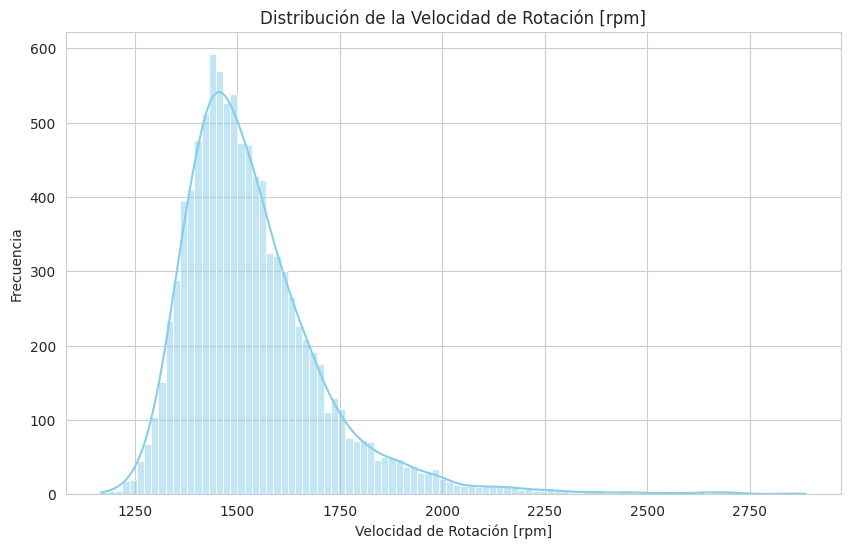

Intervalo de mayor frecuencia: [1426 – 1469] rpm
Frecuencia en ese intervalo: 1371 registros


In [10]:
# ============================================================
# PASO 3 – Análisis de Negocio
# CRISP-DM: Comprensión de los Datos
# ============================================================

# 3.1 – Histograma de Rotational speed [rpm]
plt.figure(figsize=(10, 6))
sns.histplot(df['Rotational speed [rpm]'], kde=True, color='skyblue')
plt.title('Distribución de la Velocidad de Rotación [rpm]')
plt.xlabel('Velocidad de Rotación [rpm]')
plt.ylabel('Frecuencia')
plt.show()

# Identificar intervalo de mayor frecuencia
counts, bin_edges = np.histogram(df['Rotational speed [rpm]'], bins=40)
idx_max = counts.argmax()
print(f'Intervalo de mayor frecuencia: [{bin_edges[idx_max]:.0f} – {bin_edges[idx_max+1]:.0f}] rpm')
print(f'Frecuencia en ese intervalo: {counts[idx_max]} registros')

**Nota técnica – Histograma RPM:**

La mayor concentración de registros se ubica aproximadamente entre **1.400 y 1.600 rpm**. Esto representa el **rango de operación normal** de los equipos: la mayoría de las máquinas trabaja dentro de ese intervalo sin presentar fallas. Velocidades muy por debajo o por encima de ese rango pueden indicar condiciones anómalas (sobrecarga, desbalance mecánico) con mayor riesgo de colapso.

=== FRECUENCIA ABSOLUTA ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

=== FRECUENCIA PORCENTUAL ===
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


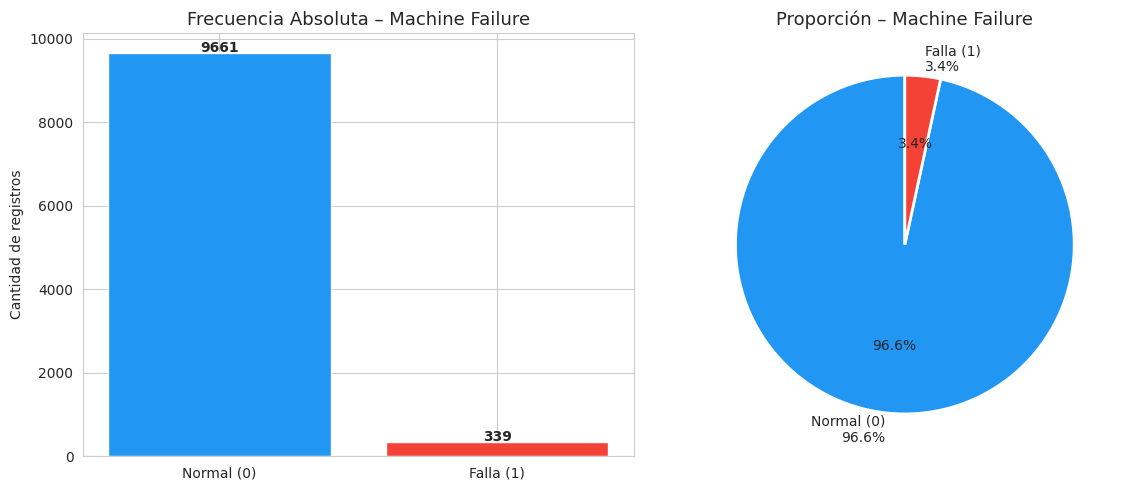

In [11]:
# 3.2 – Análisis de la Variable Objetivo: Machine failure

# Frecuencia absoluta y porcentual
freq_abs = df['Machine failure'].value_counts()
freq_pct = df['Machine failure'].value_counts(normalize=True) * 100

print('=== FRECUENCIA ABSOLUTA ===')
print(freq_abs)
print('\n=== FRECUENCIA PORCENTUAL ===')
print(freq_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras – frecuencia absoluta
etiquetas = ['Normal (0)', 'Falla (1)']
colores   = ['#2196F3', '#F44336']
axes[0].bar(etiquetas, freq_abs.values, color=colores, edgecolor='white')
axes[0].set_title('Frecuencia Absoluta – Machine Failure', fontsize=13)
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(freq_abs.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Gráfico de torta – frecuencia porcentual
labels_pie = [f'Normal (0)\n{freq_pct[0]:.1f}%', f'Falla (1)\n{freq_pct[1]:.1f}%']
axes[1].pie(
    freq_pct.values,
    labels=labels_pie,
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción – Machine Failure', fontsize=13)

plt.tight_layout()
plt.show()

**Insight de negocio – Desbalanceo de clases:**

Los datos muestran un **desbalanceo severo**: aproximadamente el **96,6% de los registros son equipos normales (clase 0)** y solo el **3,4% son fallas (clase 1)**.

Esto es un desafío crítico para la minería de datos porque:
1. El modelo tenderá a predecir siempre "sin falla" y aún así obtendrá una precisión (*accuracy*) alta (~96%), sin detectar ninguna falla real.
2. Lo que importa en el negocio es detectar la **clase minoritaria**: no detectar una falla tiene un costo altísimo (parada de planta, pérdida de equipos, riesgo de seguridad).
3. La métrica *accuracy* deja de ser confiable; hay que usar **Recall, F1-score o AUC-ROC**.
4. Se requieren técnicas de balanceo como **SMOTE, oversampling o ponderación de clases** al entrenar el modelo.

---
## FASE 3 – Preparación de los Datos
### Paso 4: Ingeniería de Características

In [12]:
# ============================================================
# PASO 4 – Ingeniería de Características
# CRISP-DM: Preparación de los Datos
# ============================================================

# Creación de la variable térmica: diferencia entre temperatura de proceso y del aire
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

print('Columna Temp_diff creada exitosamente.')
print('Vista previa con la nueva columna:')
df[['Air temperature [K]', 'Process temperature [K]', 'Temp_diff']].head()

Columna Temp_diff creada exitosamente.
Vista previa con la nueva columna:


,Air temperature [K],Process temperature [K],Temp_diff
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


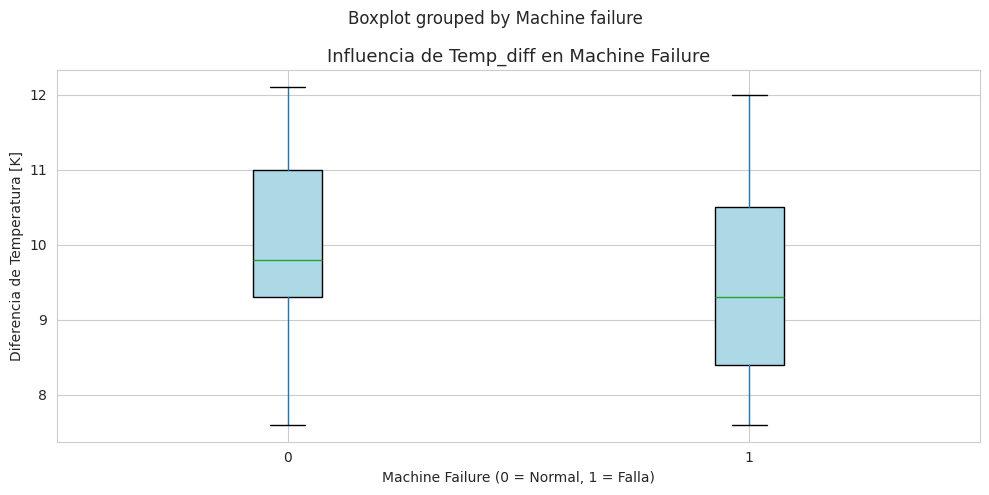

In [13]:
# Gráfico de influencia: Temp_diff vs Machine failure
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de influencia: Temp_diff vs Machine failure
fig, ax = plt.subplots(figsize=(10, 5)) # Crea una figura y un conjunto de ejes
df.boxplot(
    column='Temp_diff',
    by='Machine failure',
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    ax=ax # Pasa explícitamente los ejes para dibujar el boxplot
)

ax.set_title('Influencia de Temp_diff en Machine Failure', fontsize=13) # Aplica título a los ejes
ax.set_xlabel('Machine Failure (0 = Normal, 1 = Falla)') # Aplica etiqueta al eje X
ax.set_ylabel('Diferencia de Temperatura [K]') # Aplica etiqueta al eje Y
fig.tight_layout() # Ajusta el layout de la figura
plt.show()

**Nota técnica – Conocimiento intensional de Temp_diff:**

`Temp_diff = Process temperature - Air temperature` captura el **estrés térmico** del equipo: cuánto más caliente está el proceso respecto al ambiente. Esto aporta **conocimiento intensional** (basado en dominio industrial) porque:
- Las temperaturas por separado pueden variar juntas sin indicar problema (por ejemplo, en invierno ambas bajan al mismo tiempo).
- Lo que realmente estressa al equipo es **cuánto calor genera el proceso sobre la temperatura ambiente**.
- Si `Temp_diff` es anormalmente alta, puede indicar sobrecalentamiento → mayor probabilidad de falla.
- Esta columna **sintetiza en una sola variable** una relación física que el modelo de ML no descubriría fácilmente por sí solo a partir de las dos temperaturas independientes.

---
### Paso 5: Tratamiento de Outliers

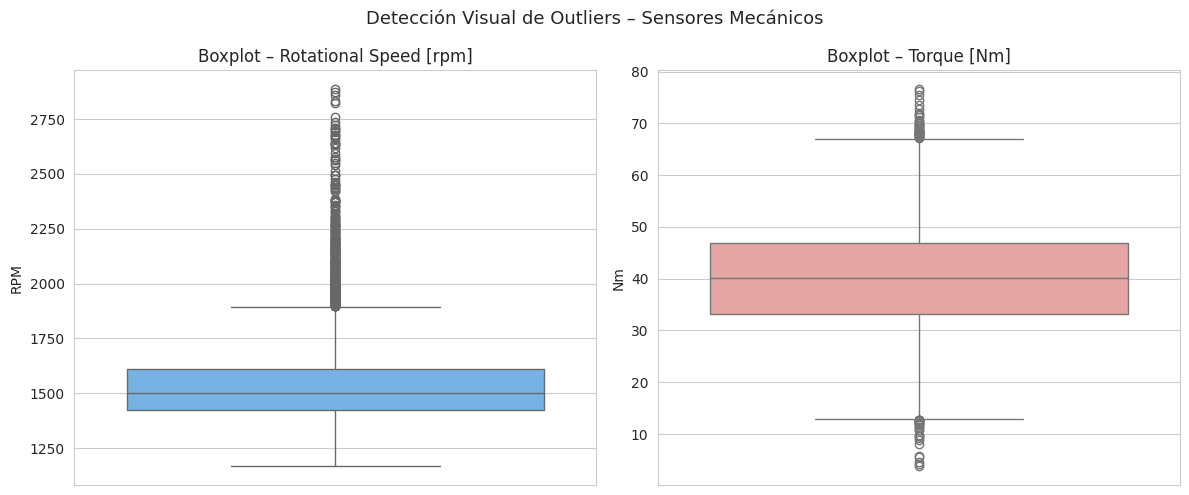

Rotational speed [rpm]: 418 outliers detectados (4.18%)
Torque [Nm]: 69 outliers detectados (0.69%)


In [14]:
# ============================================================
# PASO 5 – Detección Visual de Outliers
# CRISP-DM: Preparación de los Datos
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot: Rotational speed [rpm]
sns.boxplot(y=df['Rotational speed [rpm]'], ax=axes[0], color='#64B5F6')
axes[0].set_title('Boxplot – Rotational Speed [rpm]', fontsize=12)
axes[0].set_ylabel('RPM')

# Boxplot: Torque [Nm]
sns.boxplot(y=df['Torque [Nm]'], ax=axes[1], color='#EF9A9A')
axes[1].set_title('Boxplot – Torque [Nm]', fontsize=12)
axes[1].set_ylabel('Nm')

plt.suptitle('Detección Visual de Outliers – Sensores Mecánicos', fontsize=13)
plt.tight_layout()
plt.show()

# Cuantificación de outliers con método IQR
for col in ['Rotational speed [rpm]', 'Torque [Nm]']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers)} outliers detectados ({len(outliers)/len(df)*100:.2f}%)')

**Nota técnica – Outliers y elección de escalado:**

Los boxplots confirman la presencia de **valores atípicos en Rotational Speed y Torque** (puntos fuera de los bigotes). Esto tiene una implicancia directa en la elección del escalador:

- **MinMaxScaler** escala todos los valores al rango [0,1] usando el mínimo y máximo observados. Si existen outliers, esos extremos "comprimen" todos los valores normales hacia el centro, distorsionando las distancias entre observaciones → **no adecuado para velocidad y torque**.
- **StandardScaler** (estandarización z-score) transforma a media≈0 y desviación estándar≈1. No depende de los extremos sino de la distribución general, por lo que es más **robusto frente a outliers** → **correcto para velocidad y torque**.
- Para variables sin outliers relevantes como `Tool wear [min]`, el MinMaxScaler es apropiado.

---
### Paso 6: Preparación de Datos – Integridad y Encoding
#### 6.1 Demostración del concepto One Hot Encoding

In [15]:
# ============================================================
# PASO 6.1 – Demostración OHE (ejemplo conceptual)
# ============================================================

# Ejemplo conceptual para entender la transformación
data = ['frio', 'frio', 'templado', 'frio', 'calor', 'calor', 'templado', 'frio', 'templado', 'calor']
values = array(data)
print('Valores:', values)

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(values)
print('Label encoder integer:', integer_encoded)

onehot_encoder = OneHotEncoder(sparse_output=False)
integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)
print('One-hot encoder:\n', onehot_encoded)

inverted = label_encoder.inverse_transform([argmax(onehot_encoded[0, :])])
print('Valor invertido:', inverted)

Valores: ['frio' 'frio' 'templado' 'frio' 'calor' 'calor' 'templado' 'frio'
 'templado' 'calor']
Label encoder integer: [1 1 2 1 0 0 2 1 2 0]
One-hot encoder:
 [[0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
Valor invertido: ['frio']


La matriz junto a `one-hot-encoder` es de 10x3 porque hay tres valores distintos (calor, frío, templado). Revisando la primera fila `[0 1 0]`: el primer valor corresponde a **frío** → la primera columna representa **calor** (0), la segunda **frío** (1) y la tercera **templado** (0).

In [16]:
# ============================================================
# PASO 6.2 – OHE aplicado al dataset real + Prevención de Data Leakage
# CRISP-DM: Preparación de los Datos  ← PASO CRÍTICO
# ============================================================

# Valores únicos de la columna Type
print('Valores únicos en Type:', df['Type'].unique())

# Aplicar One Hot Encoding exclusivamente a la columna Type
df = pd.get_dummies(df, columns=['Type'], prefix='Type', drop_first=False)

# Convertir True/False a 0/1
for col in ['Type_H', 'Type_L', 'Type_M']:
    df[col] = df[col].astype(int)

print('\nOne Hot Encoding aplicado a Type.')
print('Nuevas columnas generadas:', [c for c in df.columns if c.startswith('Type_')])

Valores únicos en Type: ['M' 'L' 'H']

One Hot Encoding aplicado a Type.
Nuevas columnas generadas: ['Type_H', 'Type_L', 'Type_M']


In [17]:
# Prevención de Data Leakage:
# Las columnas TWF, HDF, PWF, OSF, RNF revelan la CAUSA de la falla
# → el modelo no tendría esa información al predecir en producción
# UDI y Product ID son identificadores que no aportan valor predictivo

columnas_leakage = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
columnas_id      = ['UDI', 'Product ID']
columnas_eliminar = columnas_leakage + columnas_id

df.drop(columns=columnas_eliminar, inplace=True)

print(f'Columnas eliminadas: {columnas_eliminar}')
print(f'\nColumnas que quedan en el DataFrame:')
print(list(df.columns))

Columnas eliminadas: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'UDI', 'Product ID']

Columnas que quedan en el DataFrame:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temp_diff', 'Type_H', 'Type_L', 'Type_M']


**Defensa de integridad – Data Leakage:**

Las columnas `TWF`, `HDF`, `PWF`, `OSF` y `RNF` indican el **tipo específico de falla** que ya ocurrió. Si se mantienen en el modelo:

1. **Invalidarían completamente el propósito predictivo**: un modelo que sabe qué tipo de falla ocurrió puede predecir trivialmente que hubo falla. Obtendrá accuracy perfecta (~100%) en entrenamiento, pero en producción esa información **nunca estará disponible** (la falla aún no ha ocurrido).
2. Es el ejemplo clásico de **Data Leakage**: información del futuro contamina el entrenamiento.
3. El modelo aprendería una correlación artificial y espuria, sin capturar los patrones reales de los sensores que anteceden a la falla.
4. Al desplegarse en producción el modelo fallaría por completo: las columnas de causa no existen antes del evento.

---
### Paso 7: Estructuración Final – Separación de Matrices

In [18]:
# ============================================================
# PASO 7 – Separación de Matrices X e y
# CRISP-DM: Preparación de los Datos
# ============================================================

# Vector objetivo: Machine failure
y = df['Machine failure']

# Matriz de características: todo lo demás
X = df.drop(columns=['Machine failure'])

print(f'Matriz X (predictores): {X.shape}')
print(f'Vector y (objetivo):    {y.shape}')
print()
print('Columnas en X:')
print(list(X.columns))

Matriz X (predictores): (10000, 9)
Vector y (objetivo):    (10000,)

Columnas en X:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Type_H', 'Type_L', 'Type_M']


---
### Paso 8: Escalamiento Mixto

In [19]:
# ============================================================
# PASO 8 – Escalamiento Mixto
# CRISP-DM: Preparación de los Datos
# ============================================================

# Columnas CON outliers → StandardScaler (robusto frente a valores extremos)
cols_standard = ['Rotational speed [rpm]', 'Torque [Nm]']

# Columnas SIN outliers relevantes → MinMaxScaler (rango [0,1])
cols_minmax = ['Air temperature [K]', 'Process temperature [K]',
               'Tool wear [min]', 'Temp_diff']

# Aplicar StandardScaler
sc = StandardScaler()
X[cols_standard] = sc.fit_transform(X[cols_standard])

# Aplicar MinMaxScaler
scaler = MinMaxScaler()
X[cols_minmax] = scaler.fit_transform(X[cols_minmax])

print('Escalamiento aplicado correctamente.')
print('  StandardScaler →', cols_standard)
print('  MinMaxScaler   →', cols_minmax)

Escalamiento aplicado correctamente.
  StandardScaler → ['Rotational speed [rpm]', 'Torque [Nm]']
  MinMaxScaler   → ['Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Temp_diff']


**Justificación técnica del escalado diferenciado:**

- **StandardScaler en velocidad y torque**: Ambos sensores presentan **outliers** (confirmado en el Paso 5). StandardScaler transforma a media≈0 y desviación estándar≈1 sin verse afectado por los extremos. Usar MinMaxScaler aquí comprimiría todos los valores normales en un rango muy estrecho, distorsionando el aprendizaje del modelo.

- **MinMaxScaler en las demás columnas**: Variables como `Tool wear [min]` tienen distribuciones más uniformes sin outliers graves. MinMaxScaler las lleva al rango [0,1], lo que es conveniente para algoritmos sensibles a magnitudes como redes neuronales o KNN.

- Las columnas binarias generadas por OHE (`Type_L`, `Type_M`, `Type_H`) **no se escalan** porque ya están en el rango {0, 1}.

In [20]:
# ============================================================
# VERIFICACIÓN FINAL – describe() de columnas escaladas
# StandardScaler: media ≈ 0, std ≈ 1
# MinMaxScaler:   min  = 0, max = 1
# ============================================================

print('=== VERIFICACIÓN StandardScaler (media ≈ 0, std ≈ 1) ===')
print(X[cols_standard].describe().round(4))

print()
print('=== VERIFICACIÓN MinMaxScaler (min = 0, max = 1) ===')
print(X[cols_minmax].describe().round(4))

print()
print('=== DATASET FINAL LISTO PARA MODELADO ===')
print(f'X: {X.shape} | y: {y.shape}')
X.head()

=== VERIFICACIÓN StandardScaler (media ≈ 0, std ≈ 1) ===
       Rotational speed [rpm]  Torque [Nm]
count              10000.0000   10000.0000
mean                  -0.0000       0.0000
std                    1.0001       1.0001
min                   -2.0682      -3.6301
25%                   -0.6458      -0.6808
50%                   -0.1996       0.0113
75%                    0.4084       0.6835
max                    7.5148       3.6729

=== VERIFICACIÓN MinMaxScaler (min = 0, max = 1) ===
       Air temperature [K]  Process temperature [K]  Tool wear [min]  \
count           10000.0000               10000.0000       10000.0000   
mean                0.5114                   0.5316           0.4267   
std                 0.2174                   0.1832           0.2516   
min                 0.0000                   0.0000           0.0000   
25%                 0.3261                   0.3827           0.2095   
50%                 0.5217                   0.5432           0.4269  

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff,Type_H,Type_L,Type_M
0,0.304348,0.358025,0.068185,0.282200,0.000000,0.644444,0,0,1
1,0.315217,0.370370,-0.729472,0.633308,0.011858,0.644444,0,1,0
2,0.304348,0.345679,-0.227450,0.944290,0.019763,0.622222,0,1,0
3,0.315217,0.358025,-0.590021,-0.048845,0.027668,0.622222,0,1,0
4,0.315217,0.370370,-0.729472,0.001313,0.035573,0.644444,0,1,0
